In [93]:
import matplotlib.pyplot as plt
from os import walk
import json
import numpy as np 

In [94]:
log_origin  = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-N01/output-resnet50-N1.out'
log_new     = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-M01/output-resnet50-M1.out'
log_new_all = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-1500-M01/output-resnet50-1500-M1.out'

log_new    = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-inception_v3-M01/output-inception_v3-O1-120.out'
log_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/results-origin/output-inception_v3-O02/output-inception_v3-O2-1500.out'

#log_new    = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-densenet_121-M01/output-densenet_121-O1-120.out'
#log_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/results-origin/output-densenet_121-O02/output-densenet_121-O2-1500.out'

log_new    = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-inception_v3-M01/output-inception_v3-O1-120.out'
log_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/results-origin/output-inception_v3-O02/output-inception_v3-O2-1500.out'

log_origin    = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/results-origin/output-resnet18-O02/output-resnet_18-O2-1500.out'
log_new = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/test/output-resnet18-O1-120.out'
log_new = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet18-M01/output-resnet18-O1-128.out'

In [95]:
f_origin  = open(log_origin, "r")
f_new     = open(log_new, "r")
#f_new_all = open(log_new_all, "r")
result_origin_dic = {}
result_new_dic = {}
result_new_all_dic = {}
for line in f_new:
    if("task tune" in line):
        result = line.split("task tune:  ")[1].replace("\n", "")
        last = result.split(" ")
        last = last[len(last)-1]
        key = result.replace(" "+last, "")
        result_new_dic[key] = float(last)
for line in f_origin:
    if("task tune" in line):
        result = line.split("task tune:  ")[1].replace("\n", "")
        last = result.split(" ")
        last = last[len(last)-1]
        key = result.replace(" "+last, "")
        result_origin_dic[key] = float(last)
#for line in f_new_all:
#    if("task tune" in line):
#        result = line.split("task tune:  ")[1].replace("\n", "")
#        last = result.split(" ")
#        last = last[len(last)-1]
#        key = result.replace(" "+last, "")
#        result_new_all_dic[key] = float(last)

In [97]:
speedup = []
speedup_all = []
for key in result_origin_dic:
    speedup.append(result_origin_dic[key]/result_new_dic[key])
    #speedup_all.append(result_origin_dic[key]/result_new_all_dic[key])

<BarContainer object of 12 artists>

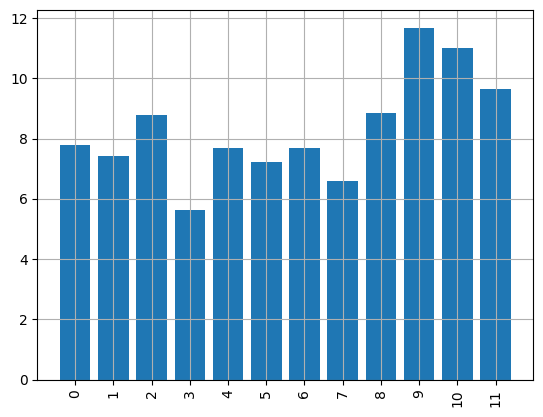

In [98]:
x = []
y = []
idx = 0
for v in np.arange(len(speedup)):
    if(v != 18 and v != 23):
        x.append(str(v))
        y.append(speedup[idx])
    idx += 1
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, y)


<BarContainer object of 0 artists>

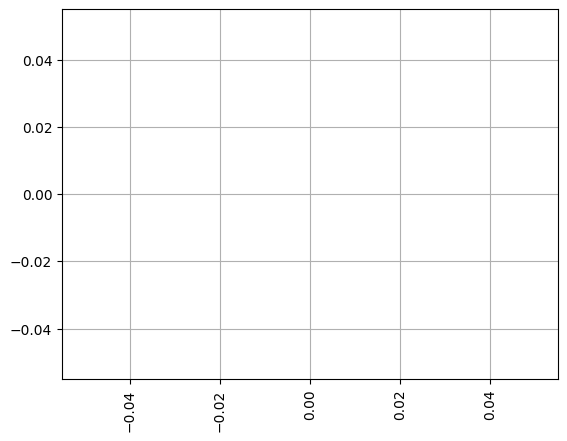

In [15]:
x = []
y = []
idx = 0
for v in np.arange(len(speedup_all)):
    if(v != 18 and v != 23):
        x.append(str(v))
        y.append(speedup_all[idx])
    idx += 1
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, y)

In [104]:
mypath_origin  = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-N01/'
mypath_new     = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-M01/'
mypath_new_all = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet50-1500-M01/'

mypath_new    = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-inception_v3-M01/'
mypath_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/results-origin/output-inception_v3-O02/'

#mypath_new    = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-densenet_121-M01/'
#mypath_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/results-origin/output-densenet_121-O02/'

mypath_new    = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/test/'
mypath_new = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet18-M01/'
mypath_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/output-resnet18-O01/'

filenames_origin  = next(walk(mypath_origin), (None, None, []))[2]  # [] if no file
filenames_new     = next(walk(mypath_new), (None, None, []))[2]  # [] if no file
filenames_new_all = next(walk(mypath_new_all), (None, None, []))[2]  # [] if no file

values_origin = {}
for name in filenames_origin:
    if(".json" in name):
        f = open(mypath_origin + name, "r")
        best = 100000
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_origin):
                values_origin[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                values_origin[task].append(r)

values_new = {}
for name in filenames_new:
    if(".json" in name):
        f = open(mypath_new + name, "r")
        best = 100000
        for line in f:
            result = json.loads(line)
            task = result['i'][0][0]
            r = sum(result['r'][0])/len(result['r'][0])
            if(task not in values_new):
                values_new[task] = []
            if(r < best):
                best = r
            if(r < 1000):
                values_new[task].append(r)

#values_new_all = {}
#for name in filenames_new_all:
#    if(".json" in name):
#        f = open(mypath_new_all + name, "r")
#        best = 100000
#        for line in f:
#            result = json.loads(line)
#            task = result['i'][0][0]
#            r = sum(result['r'][0])/len(result['r'][0])
#            if(task not in values_new_all):
#                values_new_all[task] = []
#            if(r < best):
#                best = r
#            if(r < 1000):
#                values_new_all[task].append(best)

In [105]:
speedup = []
speedup_all = []
speedup_sum = []
speedup_real = []
speedup_sum_real = []
for idx, key in enumerate(values_origin):
    if(len(values_new[key])):
        speedup.append(min(values_origin[key])/min(values_new[key]))
        #speedup_all.append(min(values_origin[key])/min(values_new_all[key]))
        #speedup_real.append(min(values_origin[key][0:64])/min(values_new_all[key][0:64]))
        #speedup_sum.append(sum(values_origin[key])/sum(values_new_all[key]))
        #speedup_sum_real.append(sum(values_origin[key][0:64])/sum(values_new[key][0:64]))

<BarContainer object of 0 artists>

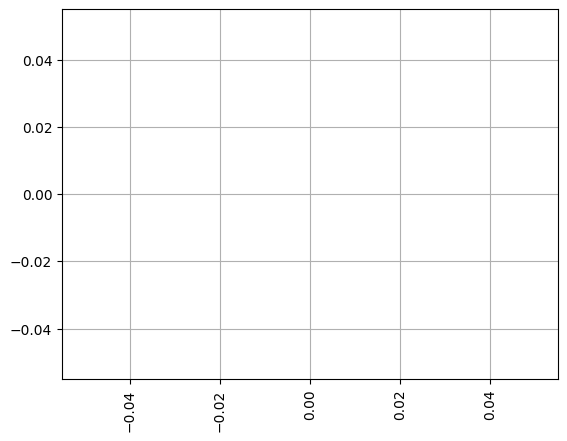

In [106]:
x = []
y = []
count = 0
for idx, v in enumerate(np.arange(len(speedup_all))):
    #if(idx != 11 and idx != 16):
    x.append(str(count))
    y.append(speedup_all[idx])
    count += 1
#plt.bar(x, speedup_sum)
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, y)

<BarContainer object of 24 artists>

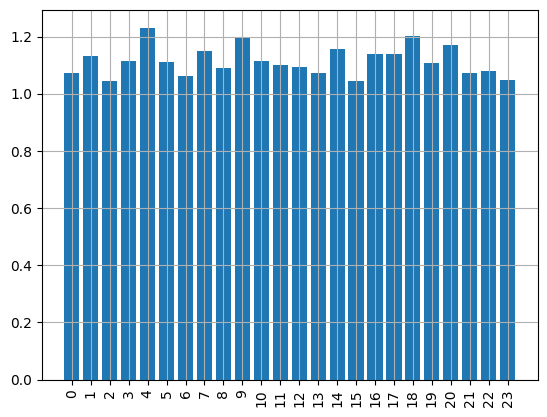

In [13]:
x = []
y = []
count = 0
for idx, v in enumerate(np.arange(len(speedup_sum))):
    if(idx != 11 and idx != 16):
        x.append(str(count))
        y.append(speedup_sum[idx])
        count += 1
#plt.bar(x, speedup_sum)
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, y)

<BarContainer object of 24 artists>

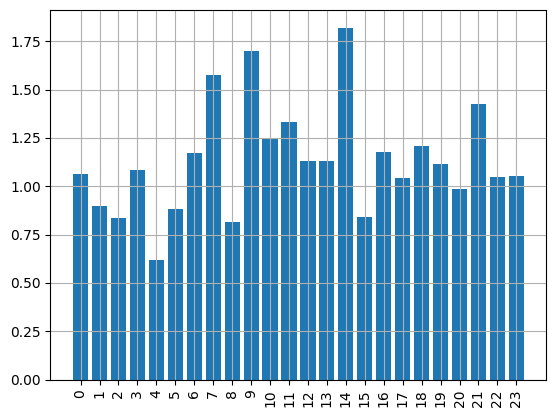

In [14]:
x = []
y = []
count = 0
for idx, v in enumerate(np.arange(len(speedup_sum_real))):
    if(idx != 11 and idx != 16):
        x.append(str(count))
        y.append(speedup_sum_real[idx])
        count += 1
#plt.bar(x, speedup_sum)
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, y)

<BarContainer object of 17 artists>

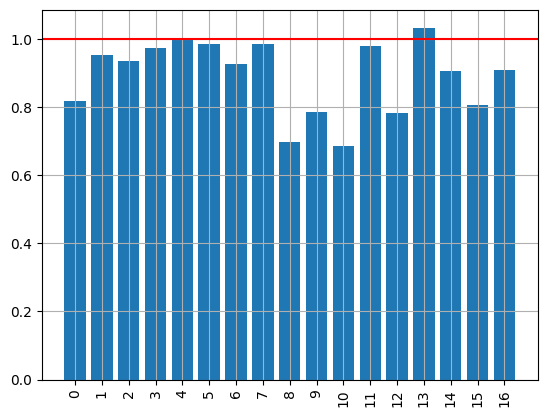

In [107]:
x = []
for v in np.arange(len(speedup)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup)

<BarContainer object of 26 artists>

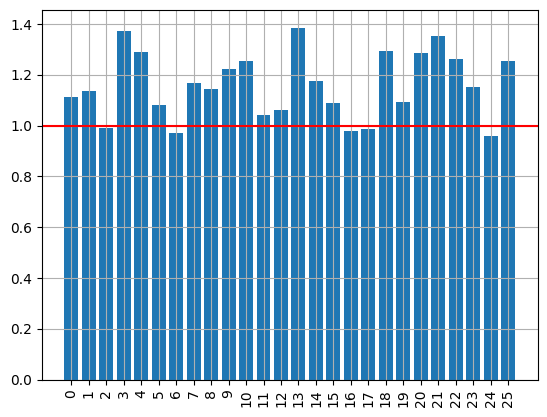

In [16]:
x = []
for v in np.arange(len(speedup_real)):
    x.append(str(v))
plt.axhline(y=1, color='r', linestyle='-')
plt.xticks(rotation=90)
plt.grid()
plt.bar(x, speedup_real)

In [37]:
for task in values_new:
    print(task)
print()
for task in values_origin:
    print(task)

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 480], [1, 1, 480, 128], [1, 1, 1, 128], [1, 14, 14, 128]]
["07f9fcad27bdd3233f86fe35a5185d33", [1, 224, 224, 3], [7, 7, 3, 64], [1, 1, 1, 64], [1, 112, 112, 64]]
["08f7449d79e570b7274174709e5e5e01", [1, 1024], [1000, 1024], [1, 1000], [1, 1000]]
["2d10de6646307f0e3e5cf4b31c20e69b", [1, 28, 28, 512], [1, 1, 512, 256], [1, 28, 28, 256]]
["6d628209072e3e3dd8f49359935acea6", [1, 56, 56, 192], [1, 1, 192, 128], [1, 1, 1, 128], [1, 56, 56, 128]]
["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 864], [1, 1, 864, 128], [1, 1, 1, 128], [1, 7, 7, 128]]
["dcee80d024ce0e9a230b3f8f573cd1fc", [1, 7, 7, 128], [3, 3, 128, 32], [1, 7, 7, 32]]
["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 992], [1, 1, 992, 128], [1, 1, 1, 128], [1, 14, 14, 128]]
["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 544], [1, 1, 544, 128], [1, 1, 1, 128], [1, 7, 7, 128]]
["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 320], [1, 1, 320, 128], [1, 1, 1, 128], [1, 28, 28, 128]]
["

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 480], [1, 1, 480, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


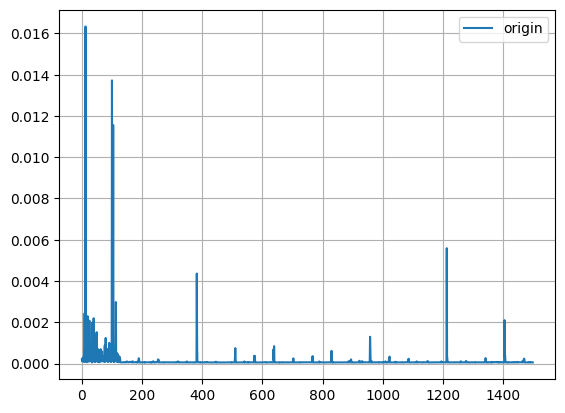

["07f9fcad27bdd3233f86fe35a5185d33", [1, 224, 224, 3], [7, 7, 3, 64], [1, 1, 1, 64], [1, 112, 112, 64]]


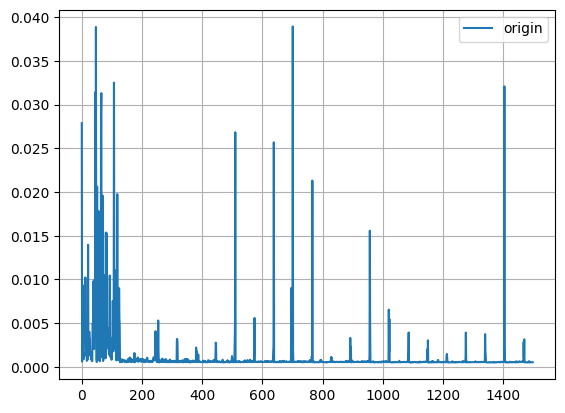

["2d10de6646307f0e3e5cf4b31c20e69b", [1, 28, 28, 512], [1, 1, 512, 256], [1, 28, 28, 256]]


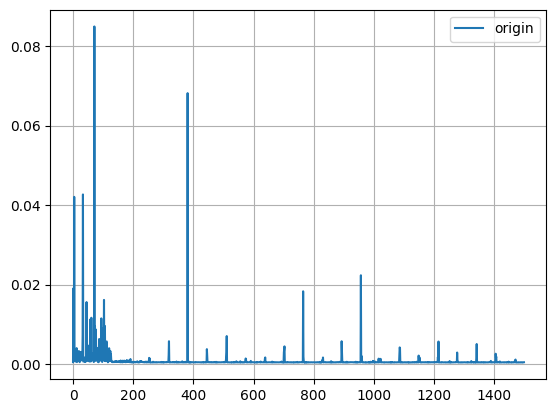

["6d628209072e3e3dd8f49359935acea6", [1, 56, 56, 192], [1, 1, 192, 128], [1, 1, 1, 128], [1, 56, 56, 128]]


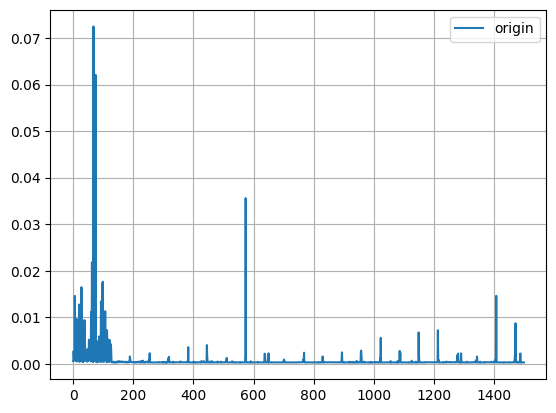

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 864], [1, 1, 864, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


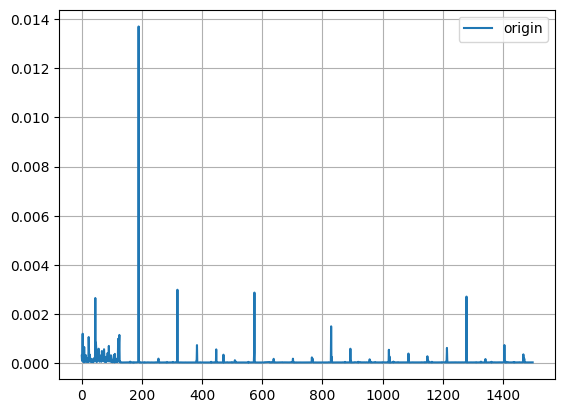

["dcee80d024ce0e9a230b3f8f573cd1fc", [1, 7, 7, 128], [3, 3, 128, 32], [1, 7, 7, 32]]


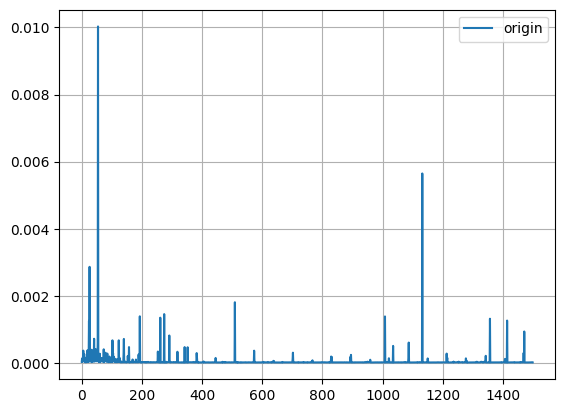

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 992], [1, 1, 992, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


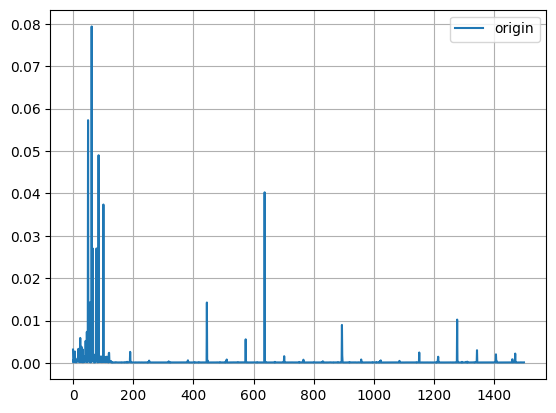

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 544], [1, 1, 544, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


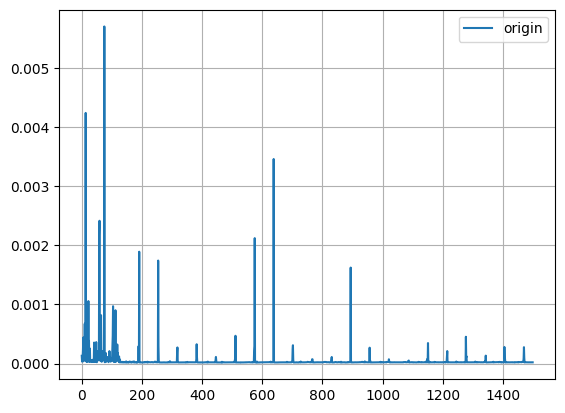

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 320], [1, 1, 320, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


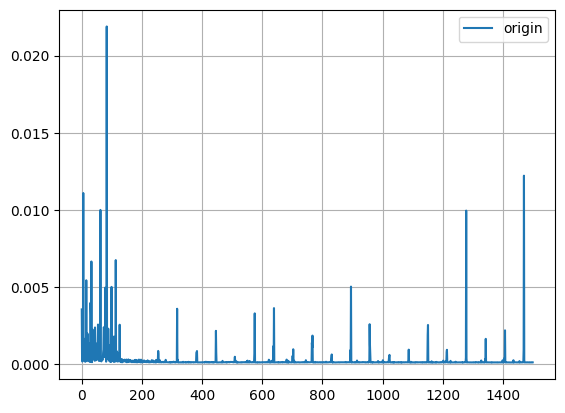

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 352], [1, 1, 352, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


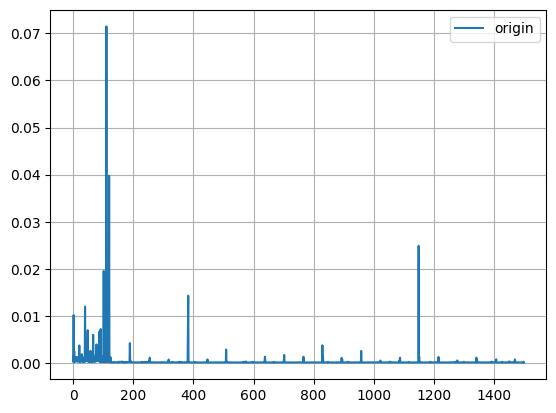

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 800], [1, 1, 800, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


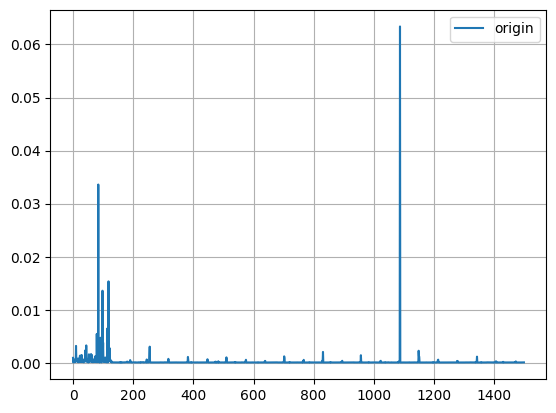

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 320], [1, 1, 320, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


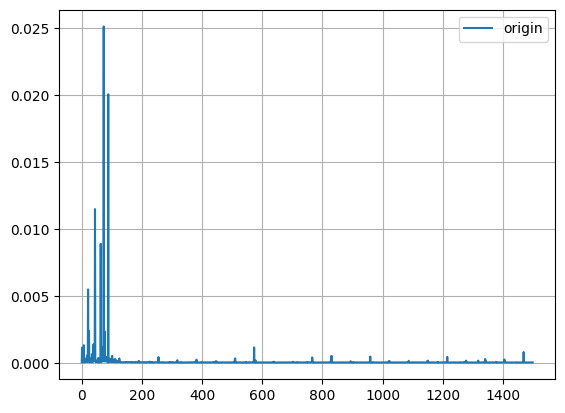

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 704], [1, 1, 704, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


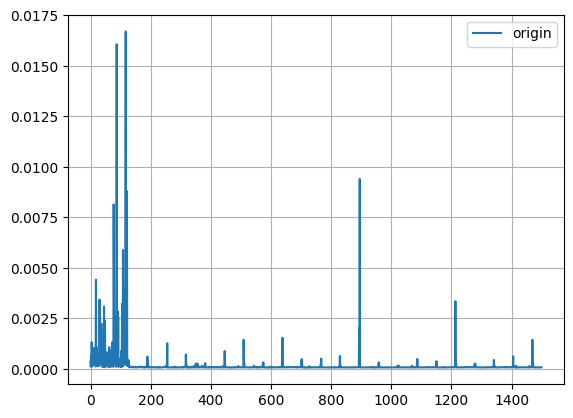

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 832], [1, 1, 832, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


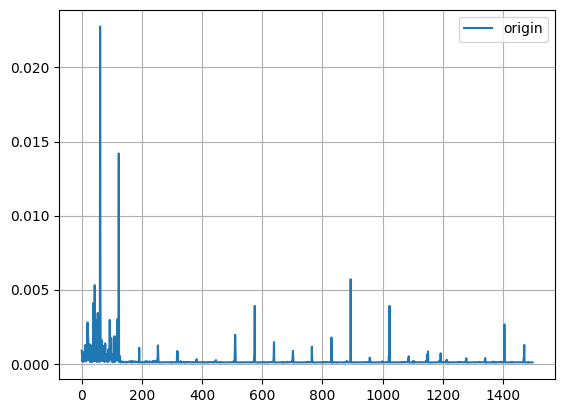

["6d628209072e3e3dd8f49359935acea6", [1, 56, 56, 128], [1, 1, 128, 128], [1, 1, 1, 128], [1, 56, 56, 128]]


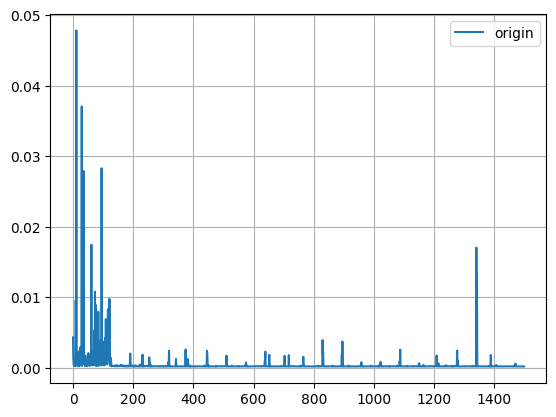

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 256], [1, 1, 256, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


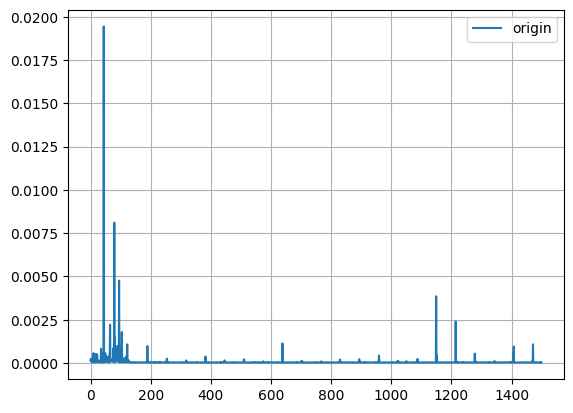

["dcee80d024ce0e9a230b3f8f573cd1fc", [1, 56, 56, 128], [3, 3, 128, 32], [1, 56, 56, 32]]


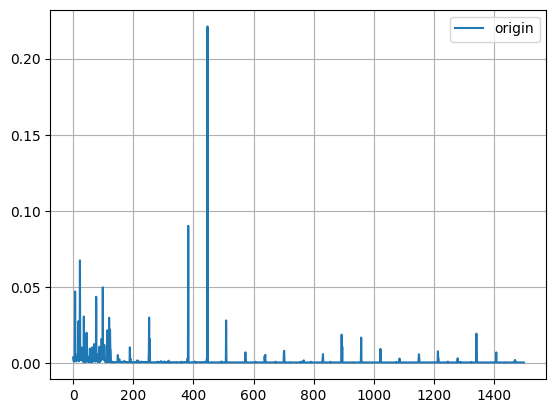

["6d628209072e3e3dd8f49359935acea6", [1, 56, 56, 64], [1, 1, 64, 128], [1, 1, 1, 128], [1, 56, 56, 128]]


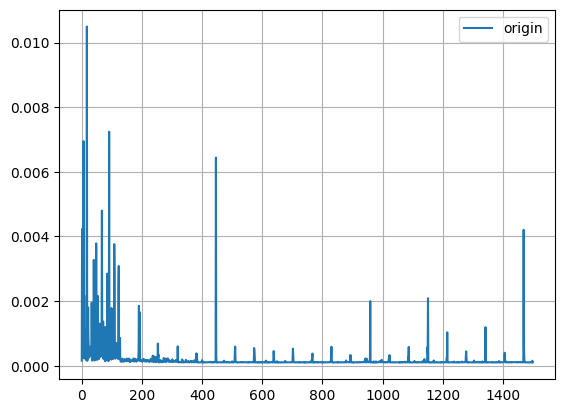

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 640], [1, 1, 640, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


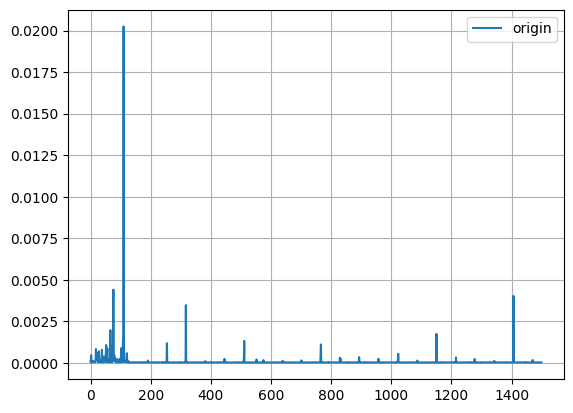

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 416], [1, 1, 416, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


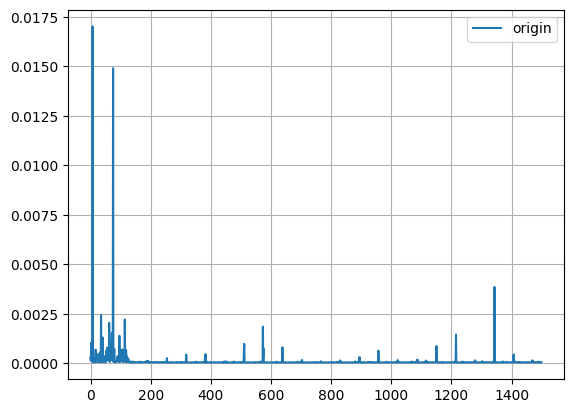

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 960], [1, 1, 960, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


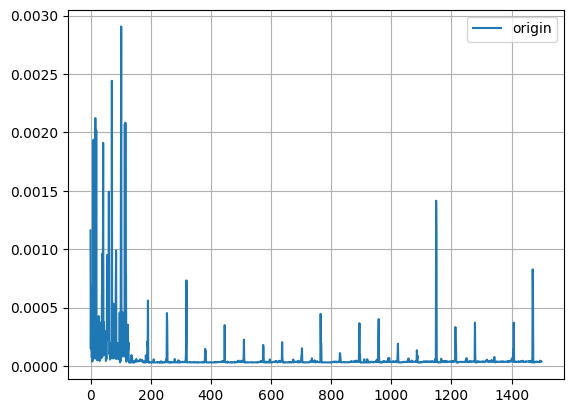

["3788955ee5407575782aa3f815485362", [1, 14, 14, 512], [1, 7, 7, 512]]


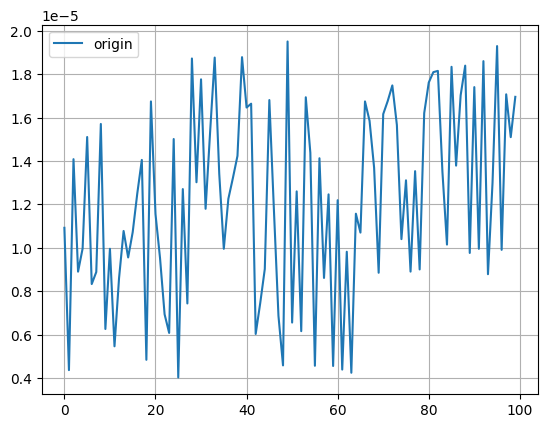

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 448], [1, 1, 448, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


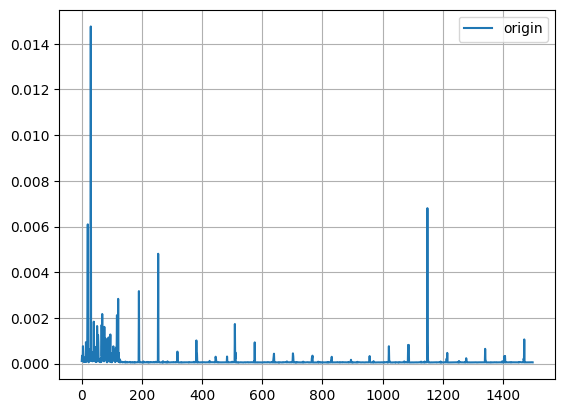

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 128], [1, 1, 128, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


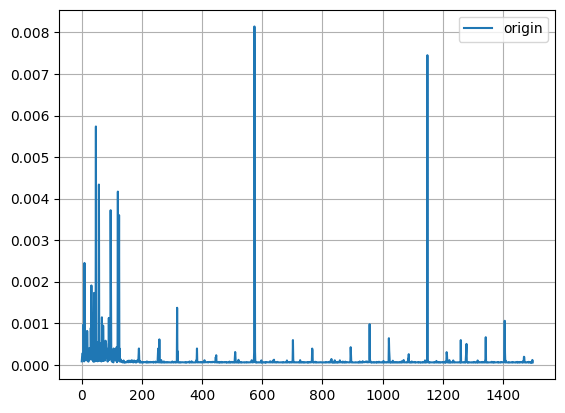

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 768], [1, 1, 768, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


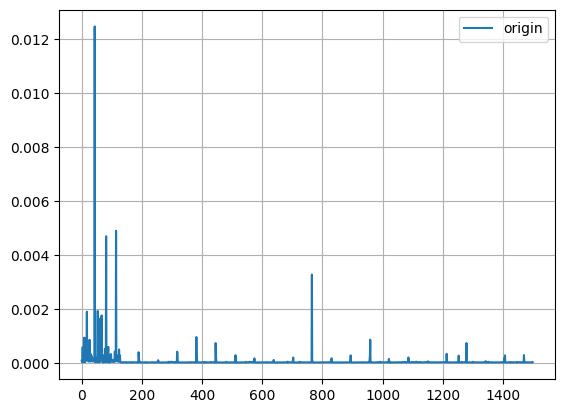

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 896], [1, 1, 896, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


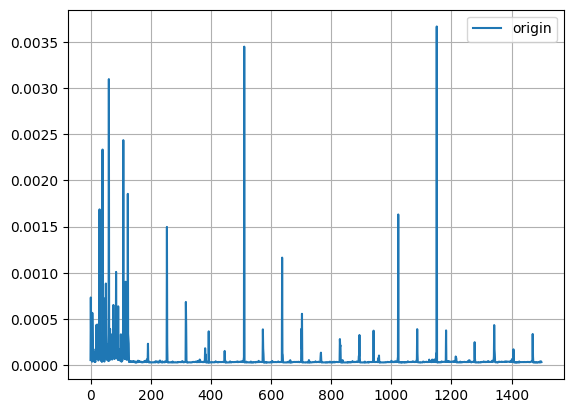

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 160], [1, 1, 160, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


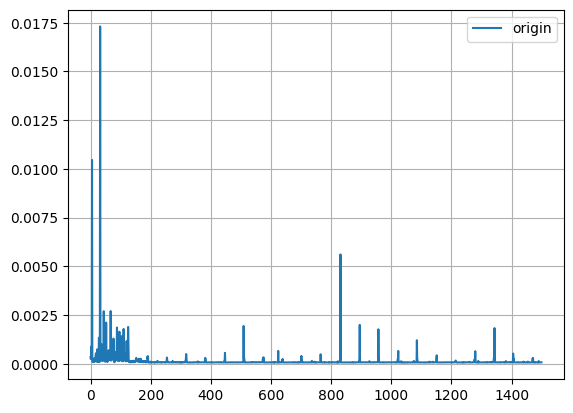

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 288], [1, 1, 288, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


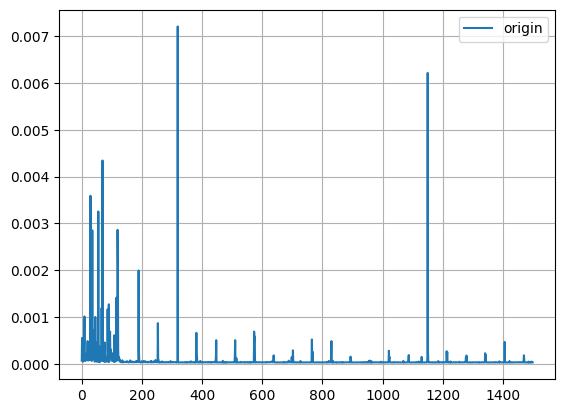

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 544], [1, 1, 544, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


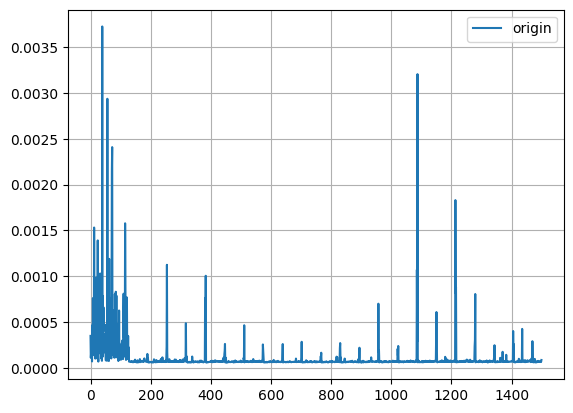

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 640], [1, 1, 640, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


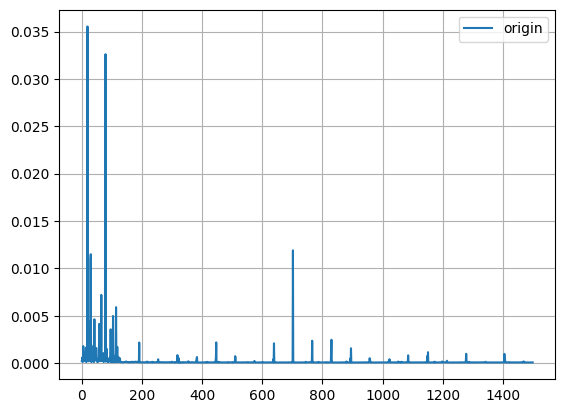

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 768], [1, 1, 768, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


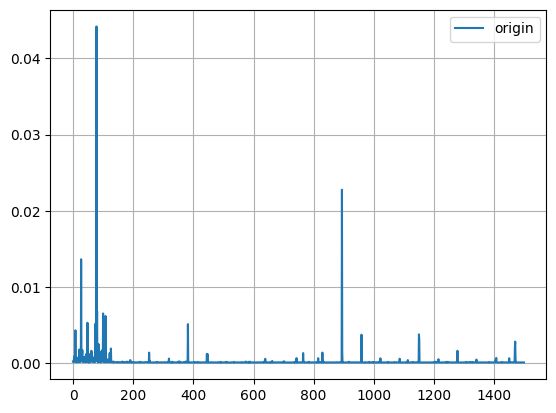

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 832], [1, 1, 832, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


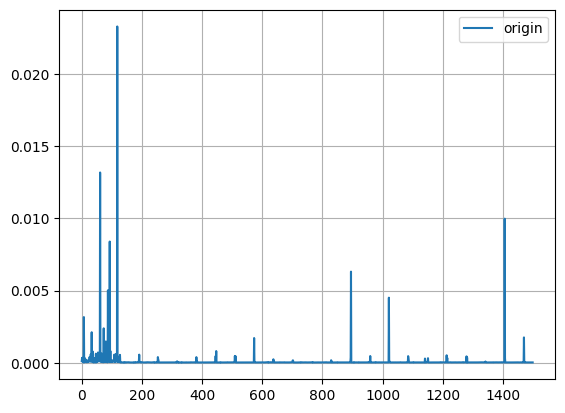

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 512], [1, 1, 512, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


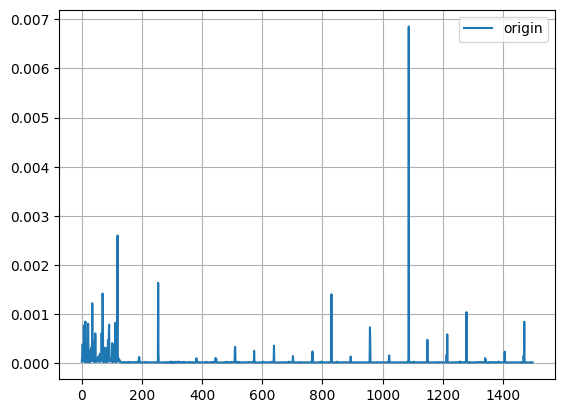

["2d10de6646307f0e3e5cf4b31c20e69b", [1, 14, 14, 1024], [1, 1, 1024, 512], [1, 14, 14, 512]]


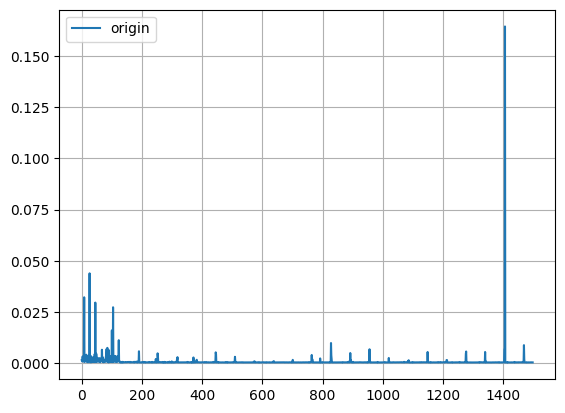

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 896], [1, 1, 896, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


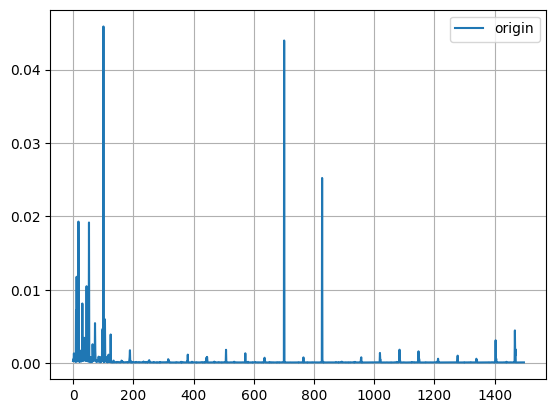

["2d10de6646307f0e3e5cf4b31c20e69b", [1, 56, 56, 256], [1, 1, 256, 128], [1, 56, 56, 128]]


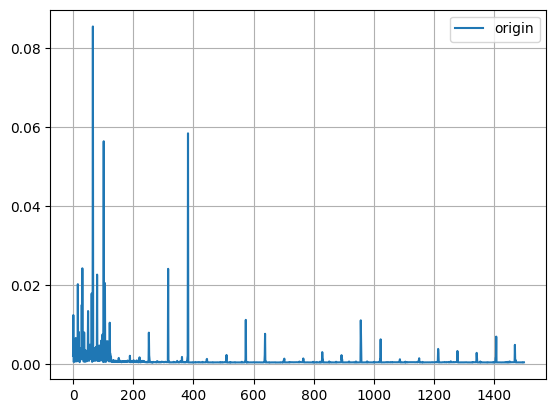

["b5f9e46659257ca03887ac95837350ca", [1, 28, 28, 256], [1, 14, 14, 256]]


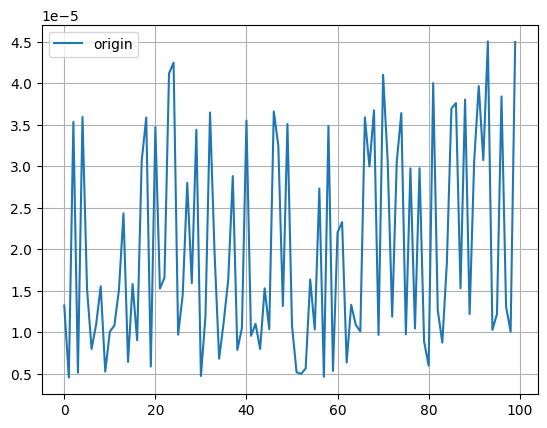

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 448], [1, 1, 448, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


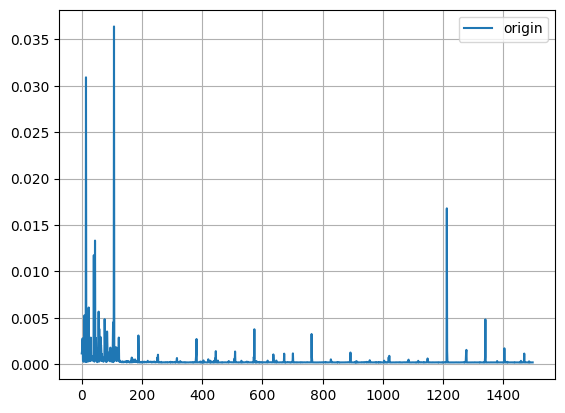

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 576], [1, 1, 576, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


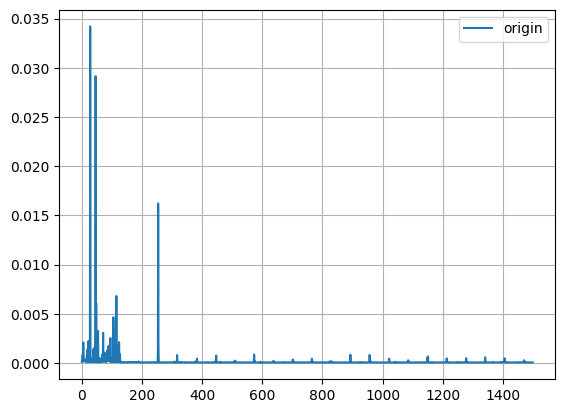

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 736], [1, 1, 736, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


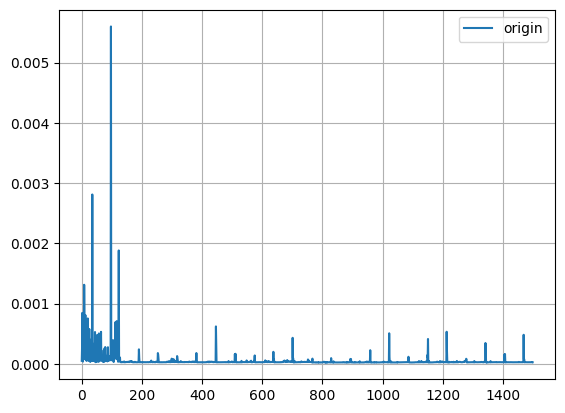

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 992], [1, 1, 992, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


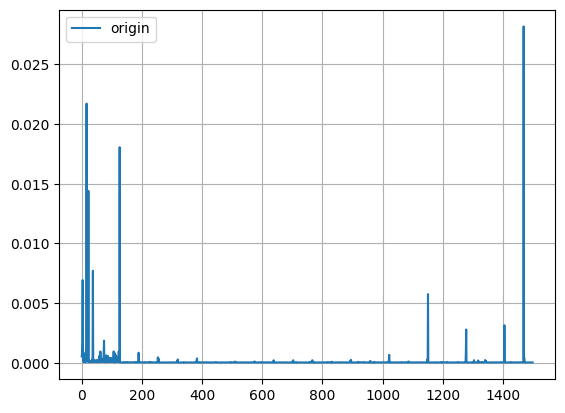

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 480], [1, 1, 480, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


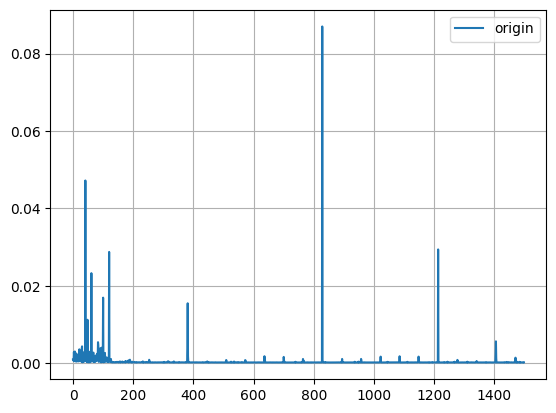

["6d628209072e3e3dd8f49359935acea6", [1, 14, 14, 672], [1, 1, 672, 128], [1, 1, 1, 128], [1, 14, 14, 128]]


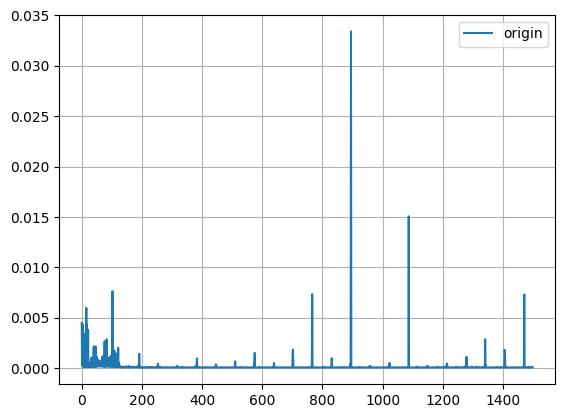

["6d628209072e3e3dd8f49359935acea6", [1, 28, 28, 224], [1, 1, 224, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


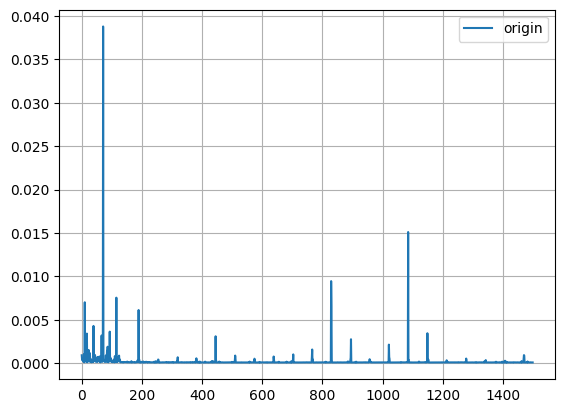

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 608], [1, 1, 608, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


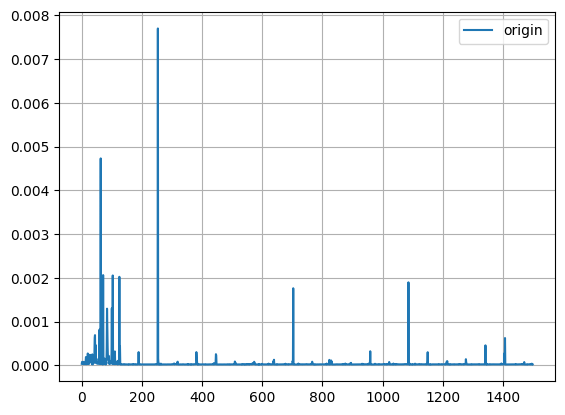

["6d628209072e3e3dd8f49359935acea6", [1, 7, 7, 672], [1, 1, 672, 128], [1, 1, 1, 128], [1, 7, 7, 128]]


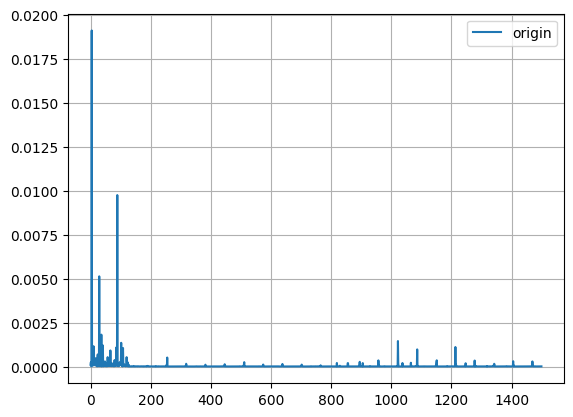

["6d628209072e3e3dd8f49359935acea6", [1, 56, 56, 160], [1, 1, 160, 128], [1, 1, 1, 128], [1, 56, 56, 128]]


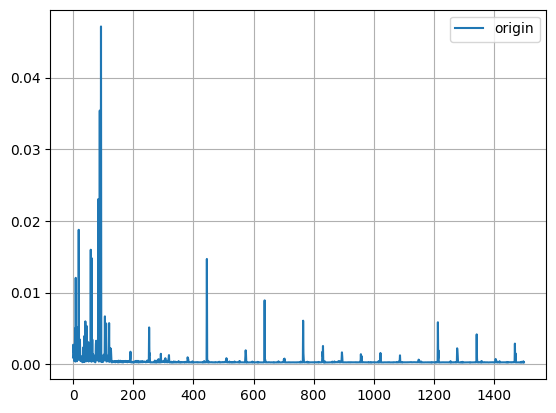

In [39]:
for idx, task in enumerate(values_new):
    if(len(values_origin[task])):
        print(task)
        #plt.figure(figsize=(25, 7))
        #plt.plot(values_origin[task][0:800])
        #plt.plot(values_new_all[task][0:800])
        plt.plot(values_origin[task], label="origin")
        #plt.plot(values_new_all[task], label="new")
        plt.legend()
        plt.grid()
        plt.show()